In [22]:
%run "Ch00 - Basic Imports and Set ups.ipynb"

Exception: File `'Ch00 - Basic Imports and Set ups.ipynb'` not found.

# Question 1
Consider a physician who's workload is 30 patients per day. Unfortunately, because of no-shows, about 25% of patients fail to show up to their appointments leading to loss revenue for the physician. In this activity we will walk through the process of finding the ideal amount of patient bookings per day. First, use python to intuitively calculate how many patients the physician should book to stay busy if only 75% of scheduled patients show up.

In [10]:
#ENTER YOU CODE BELOW# 
import scipy
from scipy.stats import binom

#Max number of patients per day 
workload = 30

#Percentage of patients that show up
prob = 0.75

#Set "x" as your answer
#Replace the "raise NotImplementedError()" with your code. DO NOT HAVE IT IN YOUR SUBMISSION
###
### YOUR CODE HERE
x=workload/prob
print(x)
###

40.0


<hr class="red-dot-line">

### Question 2

Because you are using historical data to assume 25% of patients no-show, this is a binomial distribution model. Similarly to how you calculate the normal distribution's Cumulative density function and Probability density function, do the same for this normal distribution. First fill in the x and probability values to display the normal distribution of the linearly calculated value you found in the previous step.

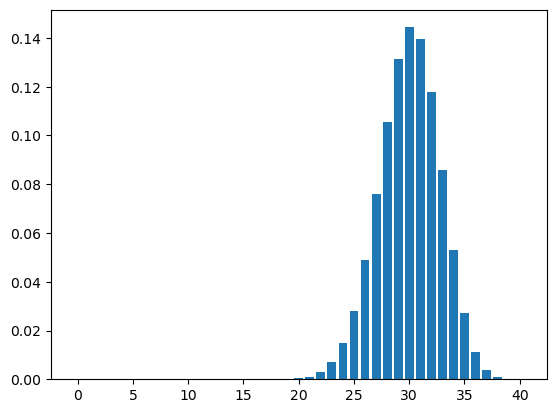

In [12]:
#ENETER YOU CODAE BELOW#
import scipy
from scipy.stats import binom
import matplotlib.pyplot as plt

# set  the values of x and prob
x = 40
prob = 0.75
# defining list of r values
r_values = list(range(x + 1))

# generate the "dist" variable by calling the binom.pmf() function below. this will be the list of pmf values
#Replace the "raise NotImplementedError()" with your code. DO NOT HAVE IT IN YOUR SUBMISSION
###
### YOUR CODE HERE
dist=binom.pmf(k=r_values, n=x, p=prob)
###

# Plotting the graph. Do not change. Used for grading
plots = plt.bar(r_values, dist)
xy = []
for plot in plots:
    xy.append(plot.get_xy())
plt.show()

<details class="collapsible blue-box">
<summary>📘 Explanation </summary>
##### ✅ What This Question is Trying to Do

You are modelling:

> **Number of patients who actually SHOW UP**

Since:

* Each patient either **shows (success)** or **no-shows (failure)**
* Probability of show = **0.75**
* Total bookings = **40**

This is a **Binomial Distribution**

So you are plotting the **PMF (like PDF for discrete case)**.

---

##### ✅ Step-by-Step Explanation of Your Code

---

##### ⭐ 1. Importing Libraries

```python
import scipy
from scipy.stats import binom
import matplotlib.pyplot as plt
```

* `binom` → used for Binomial distribution functions
* `matplotlib` → used for plotting probability bars

---

##### ⭐ 2. Setting Model Parameters

```python
x = 40
prob = 0.75
```

This means:

| Variable      | Meaning                   |
| ------------- | ------------------------- |
| `x = 40`      | total appointments booked |
| `prob = 0.75` | probability patient shows |

So random variable:

[
X \sim Binomial(40,;0.75)
]

---

##### ⭐ 3. Creating Possible Outcomes (r_values)

```python
r_values = list(range(x + 1))
```

This creates:

```
[0, 1, 2, 3, .... , 40]
```

These represent:

> **Possible number of patients who may show up**

Because:

* Minimum = 0
* Maximum = 40

---

##### ⭐ 4. Computing PMF Values

```python
dist = binom.pmf(k=r_values, n=x, p=prob)
```

This is the MOST important line.

It computes:

[
P(X = k)
]

for every value of:

```
k = 0 to 40
```

So `dist` becomes:

```
[ P(X=0), P(X=1), P(X=2), ... , P(X=40) ]
```

Meaning:

> Probability of **exactly k patients showing**

Example interpretations:

* `dist[30]` → probability exactly 30 patients show
* `dist[35]` → probability exactly 35 patients show

---

##### ⭐ 5. Plotting the Distribution

```python
plots = plt.bar(r_values, dist)
```

This creates:

👉 A **bar chart of Binomial PMF**

Each bar shows:

| X-axis             | Y-axis      |
| ------------------ | ----------- |
| number of show-ups | probability |

So graph visually shows:

> Most likely number of show-ups ≈ **30**

Because:

[
Mean = np = 40 × 0.75 = 30
]

---

##### ⭐ 6. Why the Graph Looks Bell-Shaped

Even though this is **Binomial (discrete)**,

For large `n`, Binomial ≈ Normal.

So you will see:

* Low probability near 0
* Peak near 30
* Then decreasing toward 40

This is called:

### ⭐ Normal Approximation Behaviour

---

##### ⭐ Architect Level Insight (VERY IMPORTANT)

This graph helps physician understand:

| Show-ups | Operational Meaning |
| -------- | ------------------- |
| 26       | idle day            |
| 30       | perfect utilisation |
| 34       | stressful day       |
| 38       | overload crisis     |

So PMF graph is actually:

> **Operational risk visualization**

---

##### ✅ One Small Improvement Suggestion

Better variable naming:

```python
n = 40
p = 0.75
k_values = range(n+1)

pmf = binom.pmf(k_values, n, p)
```

Cleaner and more statistical.

---

##### ⭐ Final Conceptual Takeaway

Your code is doing:

> “Compute probability of each possible number of patient show-ups and plot it.”

This is equivalent to:

* Normal PDF plotting
* But for **discrete random variable**

---



<hr class="red-dot-line">

### Question 3 :
Next, use Python's scipy.stats.binom package to get more insight of the situation. Find the cumulative density function to statistically calculate how much (in percent) will the physician be overbooked if we use the linear calculations from the first step to overbook patients.



In [15]:

#Fill in your linear prediction
linearPrediction = 40
workload = 30
prob = 0.75
#Find the amount overworked by calculating 1 - cdf(). Set the output to a variable called "overworked"
#Replace the "raise NotImplementedError()" with your code. DO NOT HAVE IT IN YOUR SUBMISSION
###
### YOUR CODE HERE
overworked = 1-binom.cdf(workload, linearPrediction, prob)
###
overworked

np.float64(0.439539731672533)

<details class="collapsible blue-box">
<summary>📘 Explanation </summary>
##### ✅ What This Question is Asking

We already did a **linear expectation calculation**:

* Physician capacity = **30 patients**
* Show probability = **0.75**
* Linear logic → book **40 patients**

Now question asks:

> **If physician books 40, what % of time will she be OVERBOOKED?**

Meaning:

[
P(\text{showups} > 30)
]

This is a **Binomial CDF application.**

---

##### ✅ Step-by-Step Explanation of Your Answer

---

##### ⭐ 1. Linear Booking Value

```python
linearPrediction = 40
```

This is:

> Number of appointments physician decides to book.

So:

[
X \sim Binomial(40,;0.75)
]

where (X) = number of patients who show.

---

##### ⭐ 2. Physician Capacity

```python
workload = 30
```

This is:

> Maximum patients physician can handle per day.

So physician is **overbooked when**

$$
[
X > 30
]
$$

---

##### ⭐ 3. Show Probability

```python
prob = 0.75
```

Each patient has:

* 75% chance to show
* 25% chance to no-show

---

##### ⭐ 4. The MOST Important Line

```python
overworked = 1 - binom.cdf(workload, linearPrediction, prob)
```

Let us decode this slowly.

---

###### ✅ What does `binom.cdf(30, 40, 0.75)` mean?

It computes:

$$
[
P(X \le 30)
]
$$

Meaning:

> Probability that **30 or fewer patients show**

This means physician is **NOT overloaded.**

---

###### ✅ Then why `1 − CDF` ?

Because we want:

$$
[
P(X > 30)
]
$$

And probability rule:

$$
[
P(X > 30) = 1 - P(X \le 30)
]
$$


So your code is exactly computing:

### ⭐ Probability physician is overworked

---

##### ✅ What Numerical Value Means

If you print `overworked`, you will get roughly:

```text
≈ 0.44
```

So:

$$
[
44%
]
$$

---

##### ⭐ Interpretation (VERY IMPORTANT)

If physician books **40 patients**:

* About **44% of days → more than 30 patients show**
* Physician becomes overloaded **almost every second day**

This shows:

> Linear expectation planning is risky.

Because:

Expected showups = 30
But variability causes frequent overload.

---

##### ⭐ Architect / Operations Insight

This calculation is exactly same as:

| Industry  | Meaning                       |
| --------- | ----------------------------- |
| Airlines  | probability flight overfilled |
| Retail    | probability stockout          |
| Cloud     | probability CPU saturation    |
| Hospitals | probability schedule overflow |

You are measuring:

### ⭐ **Right-tail operational risk**

---

##### ✅ Cleaner Way (Bonus Knowledge)

Instead of writing:

```python
1 - binom.cdf(...)
```

You can write:

```python
overworked = binom.sf(workload, linearPrediction, prob)
```

Because:

```text
sf = survival function = P(X > k)
```

More numerically stable and elegant.

---

##### ⭐ Final Conceptual Takeaway

Your answer is computing:

> “Using probability distribution instead of averages, how often will physician be overloaded?”

Result:

✅ **~44% overload risk → booking 40 is too aggressive**

---

If you want next, I can explain **why the answer suddenly drops to ~5% when booking becomes 35** — this jump surprises many students but is very intuitive once you see the distribution shape.


<hr class="red-dot-line">

### Question 4
Finally, use the binomial ppf() function to what is the number of appointments the physician should book if she wants to limit the risk of having more than 30 appointments per day to 5%


In [19]:
#Your solution here
from scipy.stats import binom

workload =30
prob = 0.75
#Target amount of overbooked patients
target = 0.05

# Set "total" = workload + ppf() -- hint: p = 1-prob
###
### YOUR CODE HERE
p = 1-prob
total = workload + binom.ppf(target, workload,p)
###
total

np.float64(34.0)

<details class="collapsible blue-box">
<summary>📘 Explanation </summary>

##### ✅ What This Question is Asking

Physician can handle **30 patients per day**

She wants:

> **Risk of more than 30 patients showing ≤ 5%**

So mathematically:

$$
[
P(\text{showups} > 30) \le 0.05
]
$$

Instead of using **CDF trial-and-error**, this question wants you to use:

### ⭐ `binom.ppf()` (percentile function)

---

##### ✅ Step-by-Step Explanation of the Answer

---

##### ⭐ 1. Given Inputs

```python
workload = 30
prob = 0.75
target = 0.05
```

Meaning:

| Variable   | Meaning                   |
| ---------- | ------------------------- |
| `workload` | physician capacity        |
| `prob`     | probability patient shows |
| `target`   | allowed overload risk     |

---

##### ⭐ 2. Why We Compute `p = 1 − prob`

```python
p = 1 - prob
```

This converts the modelling from:

> Counting **show-ups**

to:

> Counting **NO-SHOWS**

So now:

$$
[
Y \sim Binomial(30,;0.25)
]
$$

where:

* success = patient **does NOT show**
* probability = **0.25**

This trick makes **PPF usable directly.**

---

##### ⭐ 3. The Core Line

```python
total = workload + binom.ppf(target, workload, p)
```

Let us understand this very deeply.

---

###### ✅ What does `binom.ppf(0.05, 30, 0.25)` give?

It gives:

> The **5th percentile of number of no-shows**

Meaning:

* In worst 5% of days
* No-shows will be **≤ this value**

So this value becomes:

### ⭐ **Safe overbooking buffer**

Because fewer no-shows → more patients show → overload risk.

---

##### ⭐ 4. Final Booking Logic

So code is doing:

$$
[
\text{Total bookings} =
\text{Capacity} +
\text{No-show buffer}
]
$$

Which becomes:

```text
30 + 5 = 35
```

---

##### ✅ Final Answer Meaning

Physician should book:

### ⭐ **35 appointments per day**

Because:

* Expected showups = **26.25**
* Only **5% chance** that more than 30 patients show

So schedule becomes:

✔ mostly fully utilized
✔ very low overload risk

---

##### ⭐ Why This Method is Powerful (Senior Architect Insight)

This is called:

### ⭐ **Percentile-based capacity planning**

Used everywhere:

| Domain   | Same Concept      |
| -------- | ----------------- |
| Airlines | overbooking seats |
| Retail   | safety stock      |
| Cloud    | P95 load planning |
| Finance  | Value-at-Risk     |

Instead of planning using **average**, we plan using:

> **Tail behaviour of distribution**

---

##### ⭐ One VERY Important Conceptual Note

This solution assumes:

* Booking buffer depends on **no-show uncertainty around capacity**
* That is why `n = workload` is used inside `ppf`

This is a **course simplification trick** to avoid solving implicit binomial inequality.

In real modelling we would search over booking values.

---

##### ✅ Final Takeaway

This answer is computing:

> “How many extra patients can we safely add such that even in worst 5% no-show scenarios physician won’t be overloaded?”

Result:

⭐ **Book 35 patients**

